In [1]:
import pandas as pd
df=pd.read_csv("Membership.csv")

In [2]:
df['amount'].describe()

count    18183.000000
mean      3032.774402
std       4456.244413
min          7.690000
25%        100.000000
50%        100.000000
75%       7900.000000
max      16400.000000
Name: amount, dtype: float64

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

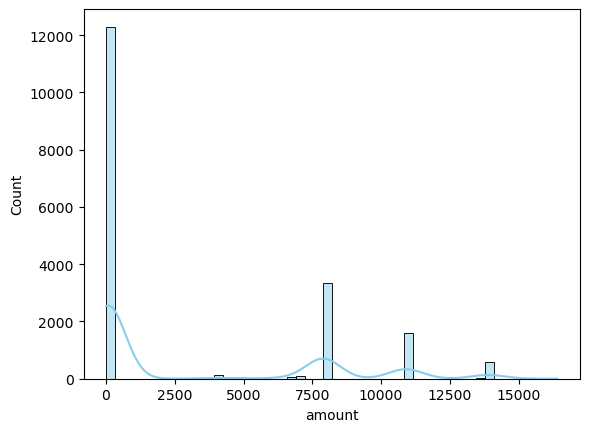

In [4]:
# sns.histplot(df['amount'],bin=50, kde=True)
sns.histplot(df['amount'], bins=50, kde=True, color='skyblue')
plt.show()

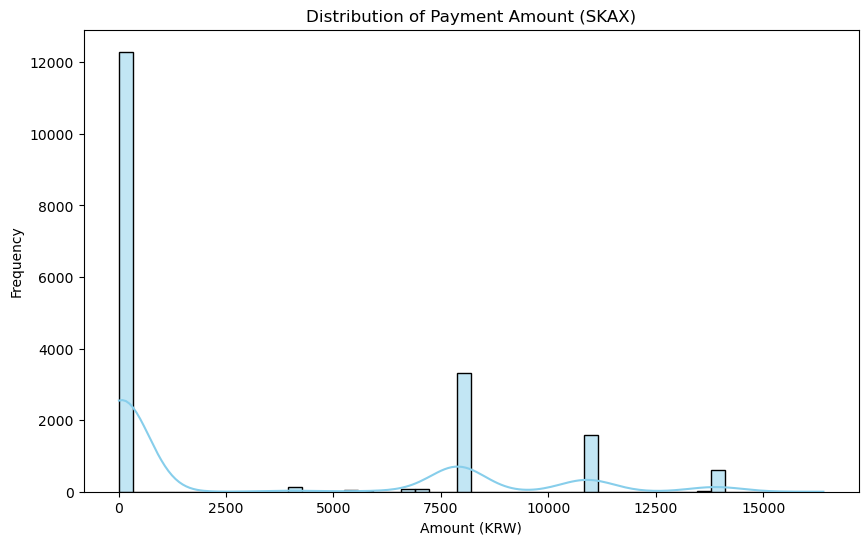

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 결제금액 히스토그램 시각화
plt.figure(figsize=(10, 6))
sns.histplot(df['amount'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Payment Amount (SKAX)')
plt.xlabel('Amount (KRW)')
plt.ylabel('Frequency')
plt.show()

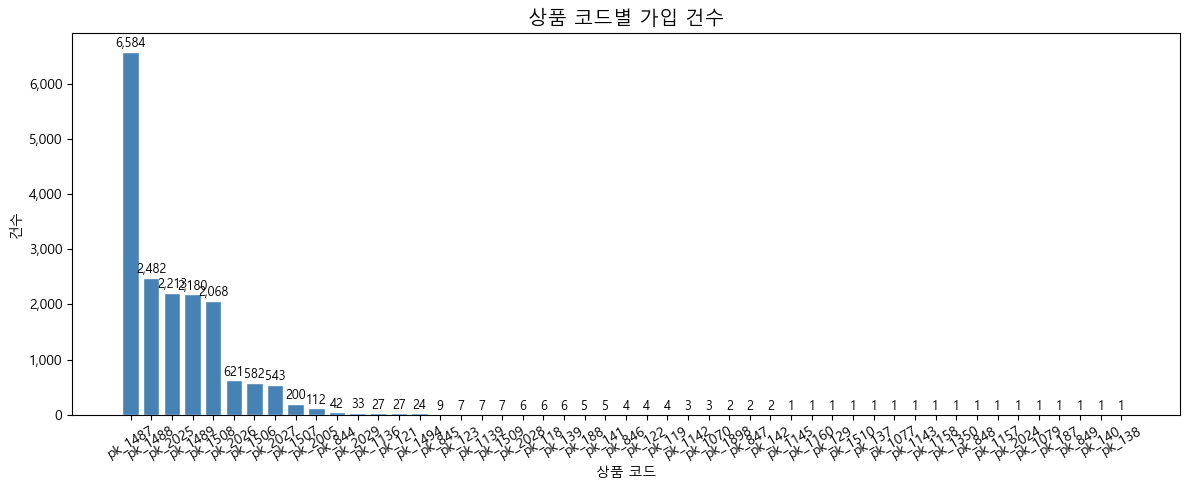

[상위 8개 상품 특성 요약]
              건수     중앙금액       평균금액    이탈률  프로모션율       상품유형
product_cd                                                   
pk_1487     6584    100.0   3106.523  0.332  0.606    무료체험/저가
pk_1488     2482  10900.0   5592.808  0.237  0.484      일반 유료
pk_1489     2180    100.0   3413.005  0.455  0.751    무료체험/저가
pk_1506      582  14839.0  14839.000  0.328  0.000  iOS 달러 상품
pk_1508     2068  10989.0  10989.000  0.365  0.000  iOS 달러 상품
pk_2025     2213    100.0   2767.646  0.305  0.653    무료체험/저가
pk_2026      621    100.0   4682.367  0.256  0.573    무료체험/저가
pk_2027      543    100.0   2170.258  0.466  0.840    무료체험/저가


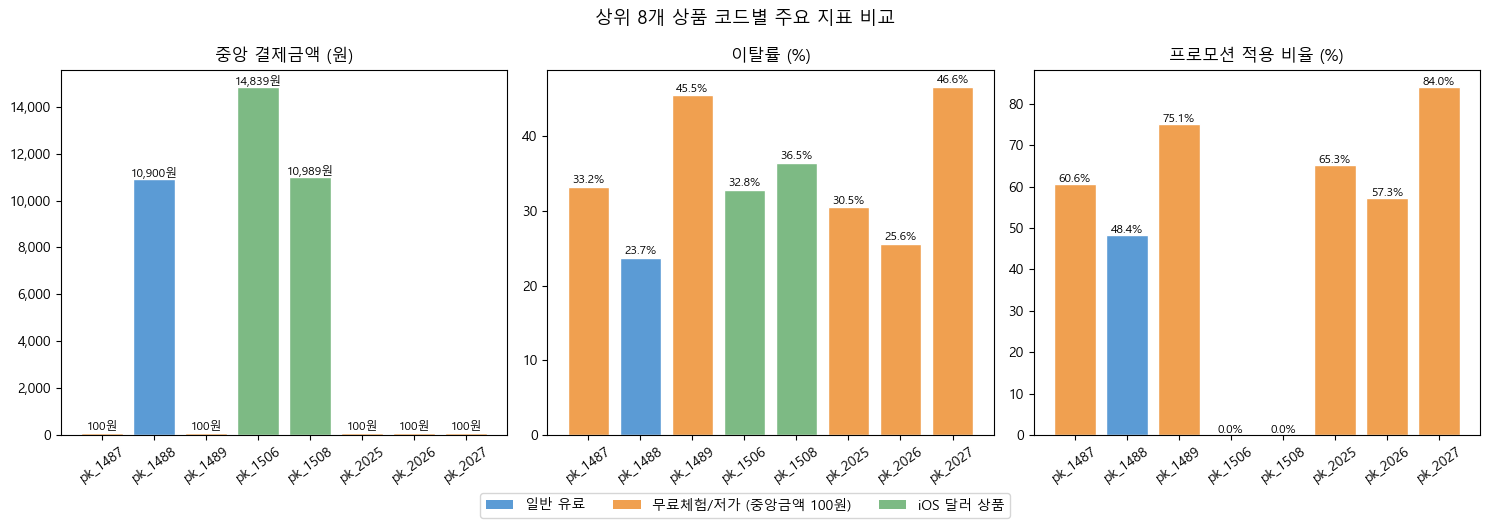


[pk_1487 집중 분석]
  건수: 6,584건 (전체의 36.9%)
  중앙 결제금액: 100원
  프로모션 비율: 60.6%
  이탈률: 33.2%
  결제기기 분포:
payment_device
android    3274
pc         1801
mobile     1509
  billing_method 분포:
billing_method
134    2456
131    1209
180    1041
132     946
190     836
170      95
160       1


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib import rc

rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('Membership_전처리.csv')
df['is_churn'] = df['repurchase'].isna().astype(int)

# ── 1. 상품 코드 건수 분포 ────────────────────────────
vc = df['product_cd'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(vc.index, vc.values, color='steelblue', edgecolor='white')
for bar, v in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('상품 코드별 가입 건수', fontsize=14)
ax.set_xlabel('상품 코드')
ax.set_ylabel('건수')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

# ── 2. 상위 8개 상품 특성 분석 ───────────────────────
TOP_N = 8
top_cds = vc.head(TOP_N).index.tolist()
sub = df[df['product_cd'].isin(top_cds)].copy()

char = sub.groupby('product_cd').agg(
    건수       = ('user_no',       'count'),
    중앙금액   = ('amount_krw',    'median'),
    평균금액   = ('amount_krw',    'mean'),
    이탈률     = ('is_churn',      'mean'),
    프로모션율 = ('promotion_yn',  lambda x: (x == 'O').mean()),
    USD여부    = ('is_usd',        'mean'),
).round(3)

char['상품유형'] = char.apply(lambda r:
    'iOS 달러 상품' if r['USD여부'] == 1.0 else
    ('무료체험/저가' if r['중앙금액'] <= 100 else '일반 유료'), axis=1)

print('[상위 8개 상품 특성 요약]')
print(char[['건수','중앙금액','평균금액','이탈률','프로모션율','상품유형']].to_string())

# ── 3. 상품 유형별 주요 지표 비교 ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('상위 8개 상품 코드별 주요 지표 비교', fontsize=13)

colors = ['#5b9bd5' if t == '일반 유료' else '#f0a050' if t == '무료체험/저가' else '#7dba84'
          for t in char['상품유형']]

# 중앙 결제금액
axes[0].bar(char.index, char['중앙금액'], color=colors, edgecolor='white')
for ax_bar, v in zip(axes[0].patches, char['중앙금액']):
    axes[0].text(ax_bar.get_x() + ax_bar.get_width()/2,
                 ax_bar.get_height() + 100,
                 f'{int(v):,}원', ha='center', fontsize=8.5)
axes[0].set_title('중앙 결제금액 (원)')
axes[0].tick_params(axis='x', rotation=35)
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 이탈률
axes[1].bar(char.index, char['이탈률'] * 100, color=colors, edgecolor='white')
for ax_bar, v in zip(axes[1].patches, char['이탈률']):
    axes[1].text(ax_bar.get_x() + ax_bar.get_width()/2,
                 v * 100 + 0.5,
                 f'{v*100:.1f}%', ha='center', fontsize=8.5)
axes[1].set_title('이탈률 (%)')
axes[1].tick_params(axis='x', rotation=35)

# 프로모션 비율
axes[2].bar(char.index, char['프로모션율'] * 100, color=colors, edgecolor='white')
for ax_bar, v in zip(axes[2].patches, char['프로모션율']):
    axes[2].text(ax_bar.get_x() + ax_bar.get_width()/2,
                 v * 100 + 0.5,
                 f'{v*100:.1f}%', ha='center', fontsize=8.5)
axes[2].set_title('프로모션 적용 비율 (%)')
axes[2].tick_params(axis='x', rotation=35)

# 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#5b9bd5', label='일반 유료'),
    Patch(facecolor='#f0a050', label='무료체험/저가 (중앙금액 100원)'),
    Patch(facecolor='#7dba84', label='iOS 달러 상품'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

# ── 4. pk_1487이 압도적으로 많은 이유 요약 ────────────
print()
print('[pk_1487 집중 분석]')
pk = df[df['product_cd'] == 'pk_1487']
print(f'  건수: {len(pk):,}건 (전체의 {len(pk)/len(df)*100:.1f}%)')
print(f'  중앙 결제금액: {pk["amount_krw"].median():,.0f}원')
print(f'  프로모션 비율: {(pk["promotion_yn"]=="O").mean()*100:.1f}%')
print(f'  이탈률: {pk["is_churn"].mean()*100:.1f}%')
print(f'  결제기기 분포:')
print(pk['payment_device'].value_counts().to_string())
print(f'  billing_method 분포:')
print(pk['billing_method'].value_counts().to_string())


=== 평균 완주율 vs 중앙값 완주율 기초 통계 ===
          평균 완주율    중앙값 완주율
count  14892.000  14892.000
mean       0.298      0.256
std        0.200      0.239
min        0.005      0.005
25%        0.153      0.045
50%        0.275      0.191
75%        0.415      0.420
max        1.000      1.000



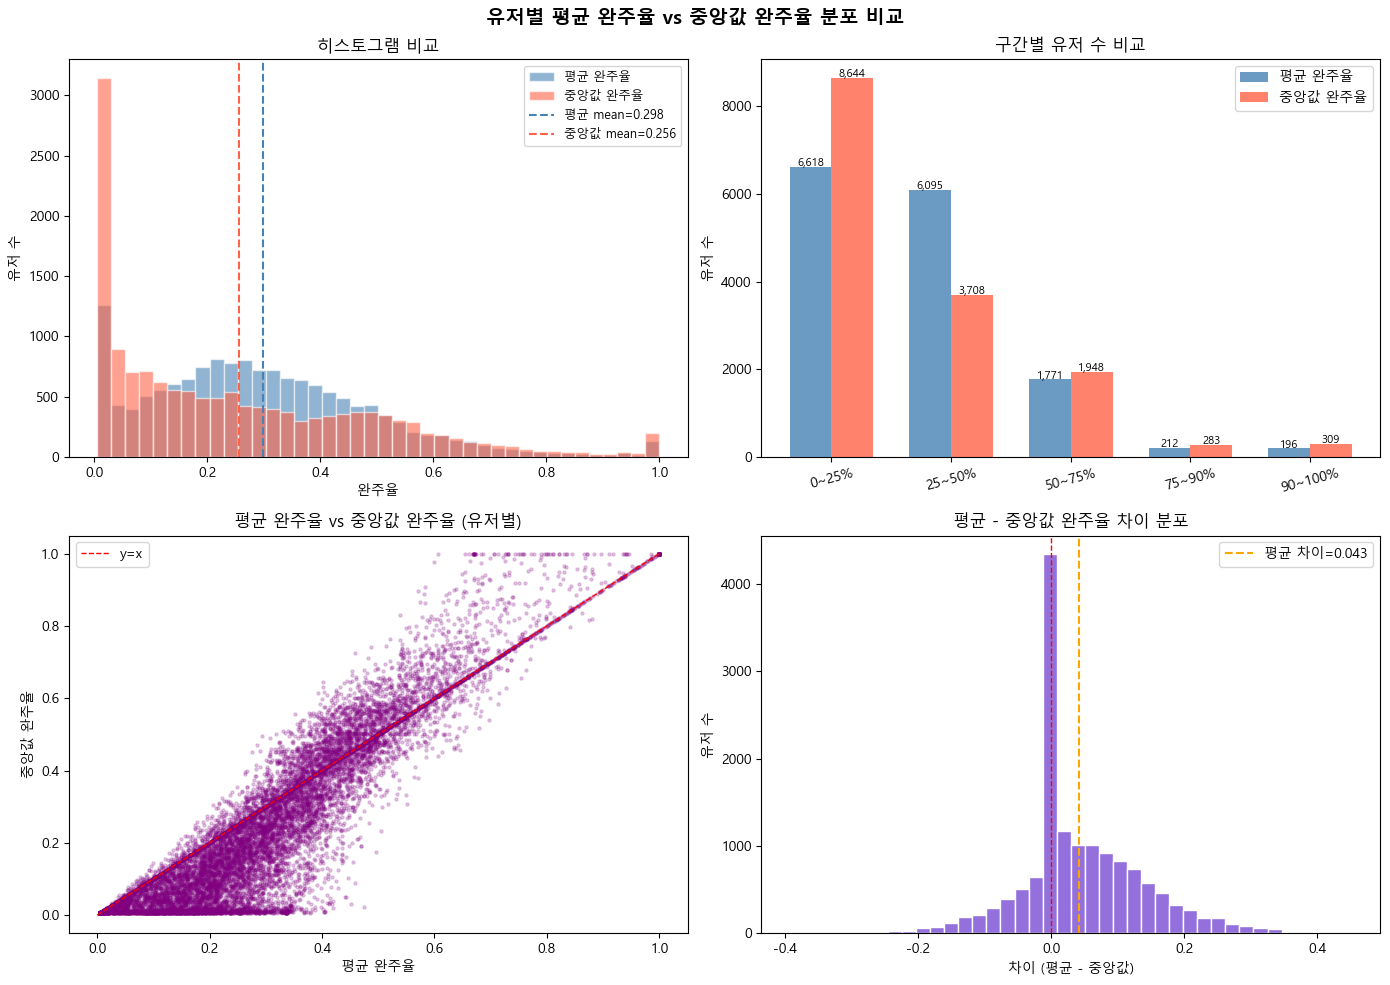


중앙값 완주율이 평균보다 낮은 유저: 8,618명 (57.9%)
중앙값 완주율이 평균보다 높은 유저: 3,156명 (21.2%)
→ 대부분 유저에서 중앙값 < 평균: 소수의 완주 세션이 평균을 끌어올리는 우편향 분포


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

vh = pd.read_csv('View_History.csv')
movie_len = vh.groupby('MOVIE_ID')['DURATION'].max().rename('max_duration').reset_index()
movie_len = movie_len[movie_len['max_duration'] > 0]
vh_comp = vh.merge(movie_len, on='MOVIE_ID', how='left')
vh_comp = vh_comp[vh_comp['max_duration'] > 0]
vh_comp['completion'] = (vh_comp['DURATION'] / vh_comp['max_duration']).clip(0, 1)

user_avg = vh_comp.groupby('USER_ID')['completion'].mean()
user_med = vh_comp.groupby('USER_ID')['completion'].median()

# ── 기초 통계 비교 ──────────────────────────────────
print('=== 평균 완주율 vs 중앙값 완주율 기초 통계 ===')
stats = pd.DataFrame({'평균 완주율': user_avg.describe(), '중앙값 완주율': user_med.describe()}).round(3)
print(stats)
print()

# ── 분포 비교 차트 ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('유저별 평균 완주율 vs 중앙값 완주율 분포 비교', fontsize=14, fontweight='bold')

# 1) 히스토그램 겹쳐서
axes[0,0].hist(user_avg, bins=40, alpha=0.6, color='steelblue', edgecolor='white', label='평균 완주율')
axes[0,0].hist(user_med, bins=40, alpha=0.6, color='tomato', edgecolor='white', label='중앙값 완주율')
axes[0,0].axvline(user_avg.mean(), color='steelblue', linestyle='--', linewidth=1.5, label=f'평균 mean={user_avg.mean():.3f}')
axes[0,0].axvline(user_med.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'중앙값 mean={user_med.mean():.3f}')
axes[0,0].set_title('히스토그램 비교')
axes[0,0].set_xlabel('완주율')
axes[0,0].set_ylabel('유저 수')
axes[0,0].legend(fontsize=9)

# 2) 평균 완주율 구간별
bins_ = [0, 0.25, 0.5, 0.75, 0.9, 1.01]
labels_ = ['0~25%', '25~50%', '50~75%', '75~90%', '90~100%']
avg_grp = pd.cut(user_avg, bins=bins_, labels=labels_).value_counts().reindex(labels_)
med_grp = pd.cut(user_med, bins=bins_, labels=labels_).value_counts().reindex(labels_)

x = range(len(labels_))
w = 0.35
bars1 = axes[0,1].bar([i-w/2 for i in x], avg_grp.values, width=w, color='steelblue', alpha=0.8, label='평균 완주율')
bars2 = axes[0,1].bar([i+w/2 for i in x], med_grp.values, width=w, color='tomato', alpha=0.8, label='중앙값 완주율')
for bar in bars1:
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                   f'{int(bar.get_height()):,}', ha='center', fontsize=8)
for bar in bars2:
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                   f'{int(bar.get_height()):,}', ha='center', fontsize=8)
axes[0,1].set_xticks(list(x))
axes[0,1].set_xticklabels(labels_, rotation=15)
axes[0,1].set_title('구간별 유저 수 비교')
axes[0,1].set_ylabel('유저 수')
axes[0,1].legend()

# 3) 산점도 (평균 vs 중앙값)
axes[1,0].scatter(user_avg, user_med, alpha=0.2, s=5, color='purple')
axes[1,0].plot([0,1],[0,1], color='red', linestyle='--', linewidth=1, label='y=x')
axes[1,0].set_title('평균 완주율 vs 중앙값 완주율 (유저별)')
axes[1,0].set_xlabel('평균 완주율')
axes[1,0].set_ylabel('중앙값 완주율')
axes[1,0].legend()

# 4) 차이(평균-중앙값) 분포
diff = user_avg - user_med
axes[1,1].hist(diff, bins=40, color='mediumpurple', edgecolor='white')
axes[1,1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1,1].axvline(diff.mean(), color='orange', linestyle='--', linewidth=1.5, label=f'평균 차이={diff.mean():.3f}')
axes[1,1].set_title('평균 - 중앙값 완주율 차이 분포')
axes[1,1].set_xlabel('차이 (평균 - 중앙값)')
axes[1,1].set_ylabel('유저 수')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# ── 핵심 인사이트 출력 ──────────────────────────────
print()
print(f'중앙값 완주율이 평균보다 낮은 유저: {(user_med < user_avg).sum():,}명 ({(user_med < user_avg).mean()*100:.1f}%)')
print(f'중앙값 완주율이 평균보다 높은 유저: {(user_med > user_avg).sum():,}명 ({(user_med > user_avg).mean()*100:.1f}%)')
print(f'→ 대부분 유저에서 중앙값 < 평균: 소수의 완주 세션이 평균을 끌어올리는 우편향 분포')


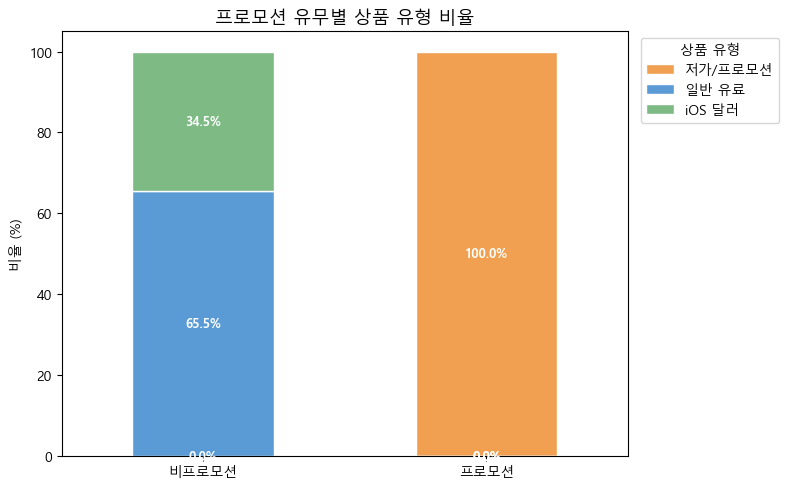

prod_type  저가/프로모션  일반 유료  iOS 달러
비프로모션          0.0   65.5    34.5
프로모션         100.0    0.0     0.0


C:\Users\82109\AppData\Local\Temp\ipykernel_18184\2758246148.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = ms.groupby('promo').apply(lambda x: pd.Series({


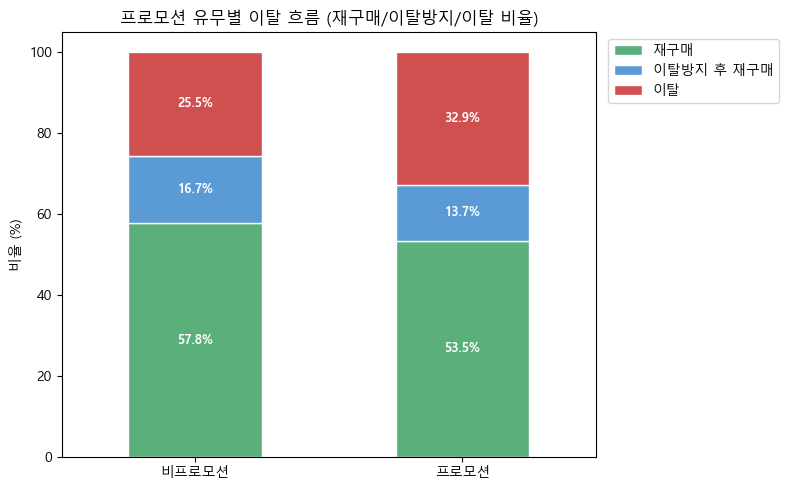

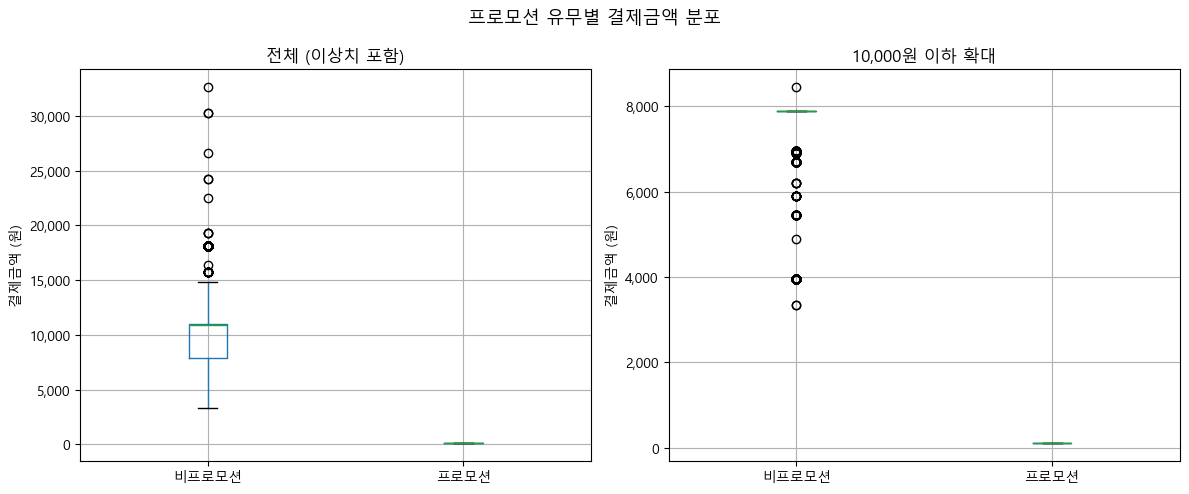

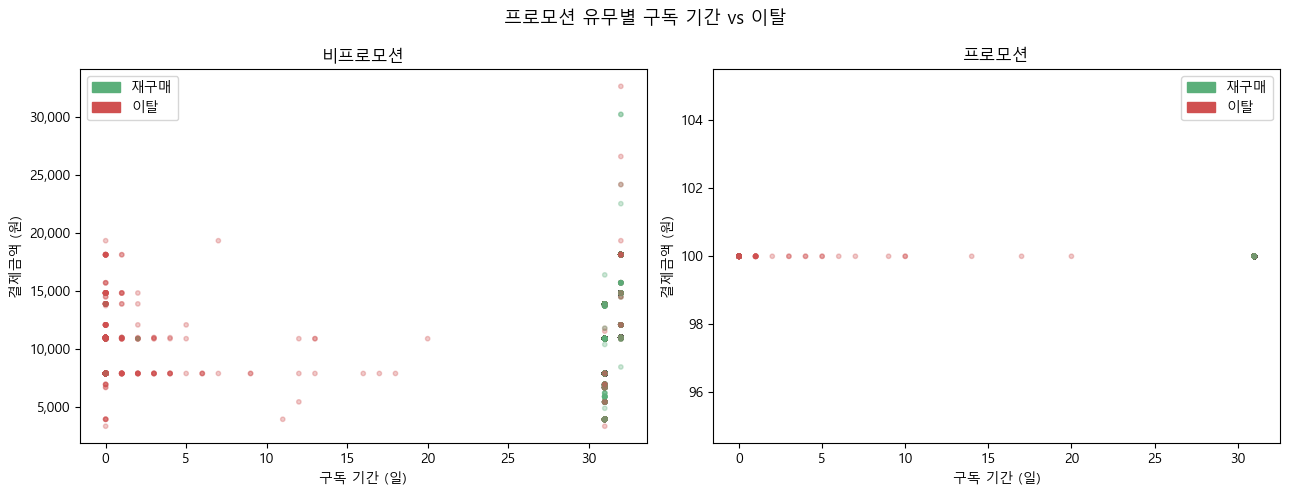

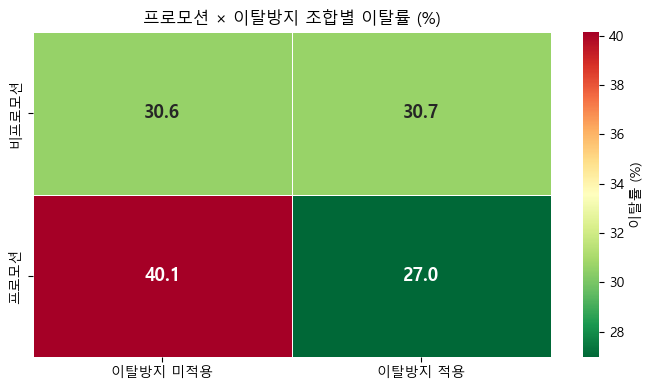


[프로모션 × 이탈방지 조합별 이탈률]
이탈방지   이탈방지 미적용  이탈방지 적용
프로모션                    
비프로모션      30.6     30.7
프로모션       40.1     27.0


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
from matplotlib import rc

rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

ms = pd.read_csv('Membership.csv')
ms['is_usd'] = ms['amount'] % 1 != 0
ms['amount_krw'] = ms.apply(lambda x: round(x['amount']*1100) if x['is_usd'] else x['amount'], axis=1)
ms['is_churn'] = ms['repurchase'].isna().astype(int)
ms['promo'] = ms['promotion_yn'].eq('O')

# 상품 유형 분류
def prod_type(row):
    if row['is_usd']: return 'iOS 달러'
    elif row['amount_krw'] <= 100: return '저가/프로모션'
    else: return '일반 유료'
ms['prod_type'] = ms.apply(prod_type, axis=1)

# ── 차트 1: 프로모션 유무별 상품 유형 비율 ─────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(ms['prod_type'], ms['promo'], normalize='columns') * 100
ct.columns = ['비프로모션', '프로모션']
ct = ct.reindex(['저가/프로모션', '일반 유료', 'iOS 달러'])
ct.T.plot(kind='bar', ax=ax, color=['#f0a050','#5b9bd5','#7dba84'], edgecolor='white', stacked=True)
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt='%.1f%%', label_type='center', fontsize=9, color='white', fontweight='bold')
ax.set_title('프로모션 유무별 상품 유형 비율', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('비율 (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='상품 유형', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()
print(ct.T.round(1))

# ── 차트 2: 프로모션 유저 이탈 흐름 (누적 막대) ───────────
fig, ax = plt.subplots(figsize=(8, 5))
result = ms.groupby('promo').apply(lambda x: pd.Series({
    '재구매': (x['repurchase']=='O').sum(),
    '이탈방지 후 재구매': (x['is_churn_prevented']=='O').sum(),
    '이탈': x['is_churn'].sum()
})).reset_index()
result.index = ['비프로모션', '프로모션']
result = result.drop(columns='promo')
total = result.sum(axis=1)
result_pct = result.div(total, axis=0) * 100
colors = ['#5baf7a', '#5b9bd5', '#d05050']
result_pct.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='white')
for bar_group in ax.containers:
    ax.bar_label(bar_group, fmt='%.1f%%', label_type='center', fontsize=9, color='white', fontweight='bold')
ax.set_title('프로모션 유무별 이탈 흐름 (재구매/이탈방지/이탈 비율)', fontsize=12)
ax.set_ylabel('비율 (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# ── 차트 3: 결제금액 분포 비교 (박스플롯) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('프로모션 유무별 결제금액 분포', fontsize=13)

# 전체
ms.boxplot(column='amount_krw', by='promo', ax=axes[0])
axes[0].set_title('전체 (이상치 포함)')
axes[0].set_xlabel('')
axes[0].set_xticklabels(['비프로모션', '프로모션'])
axes[0].set_ylabel('결제금액 (원)')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.sca(axes[0]); plt.title('전체 (이상치 포함)')

# 10,000원 이하 확대
ms[ms['amount_krw'] <= 10000].boxplot(column='amount_krw', by='promo', ax=axes[1])
axes[1].set_title('10,000원 이하 확대')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['비프로모션', '프로모션'])
axes[1].set_ylabel('결제금액 (원)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.sca(axes[1]); plt.title('10,000원 이하 확대')

plt.suptitle('프로모션 유무별 결제금액 분포', fontsize=13)
plt.tight_layout()
plt.show()

# ── 차트 4: 구독기간 vs 이탈 (프로모션별) ─────────────────
ms['reg_date'] = pd.to_datetime(ms['reg_date'])
ms['end_date'] = pd.to_datetime(ms['end_date'])
ms['sub_days'] = (ms['end_date'] - ms['reg_date']).dt.days

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('프로모션 유무별 구독 기간 vs 이탈', fontsize=13)

for ax, (label, grp) in zip(axes, ms.groupby('promo')):
    title = '프로모션' if label else '비프로모션'
    colors_ = grp['is_churn'].map({0:'#5baf7a', 1:'#d05050'})
    ax.scatter(grp['sub_days'], grp['amount_krw'], c=colors_, alpha=0.3, s=10)
    ax.set_title(title)
    ax.set_xlabel('구독 기간 (일)')
    ax.set_ylabel('결제금액 (원)')
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='#5baf7a', label='재구매'), Patch(color='#d05050', label='이탈')])

plt.tight_layout()
plt.show()

# ── 차트 5: 프로모션 × 이탈방지 교차 히트맵 ───────────────
fig, ax = plt.subplots(figsize=(7, 4))
ms['이탈방지'] = ms['is_churn_prevented'].eq('O').map({True:'이탈방지 적용', False:'이탈방지 미적용'})
ms['프로모션'] = ms['promo'].map({True:'프로모션', False:'비프로모션'})
pivot = ms.pivot_table(values='is_churn', index='프로모션', columns='이탈방지', aggfunc='mean') * 100
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label': '이탈률 (%)'}, annot_kws={'size':13, 'fontweight':'bold'})
ax.set_title('프로모션 × 이탈방지 조합별 이탈률 (%)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
print()
print('[프로모션 × 이탈방지 조합별 이탈률]')
print(pivot.round(1))
